In [11]:
import os
import base64
import json
import random
from openai import OpenAI
import anthropic
import numpy as np
import re
from tqdm import tqdm
import pandas as pd
import time
from dotenv import load_dotenv
import matplotlib.pyplot as plt
import copy

# Load dataset

In [ ]:
# Set base directory using relative path
base_dir = os.path.join(os.getcwd(), "dataset", "pororo")
qa_json_path = os.path.join(base_dir, "qa.json")
description_csv_path = os.path.join(base_dir, "descriptions.csv")

def load_dataset(qa_json_path, description_csv_path):
    try:
        with open(qa_json_path, "r") as f:
            qa_data = json.load(f)["PororoQA"]
        descriptions = pd.read_csv(description_csv_path)
        return qa_data, descriptions
    except Exception as e:
        print(f"Error loading dataset: {e}")
        return [], pd.DataFrame()

# Initialize a single cached dataset dictionary, similar to pororo_ablation_study.ipynb
cached_dataset = None

# Function to get a fresh copy of the dataset
def get_fresh_dataset(reload=False):
    """Get a fresh, isolated copy of the dataset to prevent cross-configuration contamination"""
    global cached_dataset
    
    # Load from disk if not cached or forced reload
    if cached_dataset is None or reload:
        print("Loading dataset from disk...")
        qa_data, descriptions = load_dataset(qa_json_path, description_csv_path)
        cached_dataset = {
            'qa_data': qa_data,
            'descriptions': descriptions,
            'gif_paths': {},
            'question_data': {}
        }
    else:
        print("Using cached dataset but creating a deep copy to prevent contamination...")
    
    # Always return deep copies to prevent cross-configuration contamination
    return copy.deepcopy(cached_dataset['qa_data']), \
           cached_dataset['descriptions'].copy(deep=True)

# TODO increase questions
def get_random_questions(qa_data, max_questions=40, base_pattern="Pororo_ENGLISH1", seed=42):
    random.seed(seed)

    # Filter all eligible questions
    filtered_questions = [q for q in qa_data if base_pattern in q["video_name"]]

    # Group by unique (video_name, supporting_num) pairs to avoid duplicates
    unique_pairs = {}
    for q in filtered_questions:
        key = (q["video_name"], q["supporting_num"])
        if key not in unique_pairs:
            unique_pairs[key] = []
        unique_pairs[key].append(q)

    # Sample from unique pairs
    unique_keys = list(unique_pairs.keys())
    selected_keys = random.sample(unique_keys, min(max_questions, len(unique_keys)))

    # Get one question from each selected pair
    sampled_questions = []
    episode_counts = {}

    for key in selected_keys:
        question = random.choice(unique_pairs[key])
        sampled_questions.append(question)
        episode = question["video_name"]
        episode_counts[episode] = episode_counts.get(episode, 0) + 1

    # Group by season for display
    season_episodes = {
        "Pororo_ENGLISH1_1": [],
        "Pororo_ENGLISH1_2": [],
        "Pororo_ENGLISH1_3": []
    }

    for ep in episode_counts.keys():
        season = "_".join(ep.split("_")[:3])
        if season in season_episodes:
            season_episodes[season].append(ep)

    # Do not print here; return the info for printing elsewhere
    return sampled_questions, episode_counts, season_episodes

def get_seeded_question(questions, gif_num, base_seed=42):
    """Get deterministic random question for a GIF"""
    if not questions:
        return None
    local_random = random.Random(base_seed + gif_num)
    sorted_questions = sorted(questions, key=lambda x: x["qid"])
    return local_random.choice(sorted_questions)

def encode_gif(gif_path):
    try:
        if not os.path.exists(gif_path):
            print(f"Error: GIF not found at {gif_path}")
            return None
        with open(gif_path, "rb") as gif_file:
            image_base64 = base64.b64encode(gif_file.read()).decode('utf-8')
            return image_base64
    except Exception as e:
        print(f"Error encoding GIF: {e}")
        return None

def prepare_dataset():
    """Prepare a fresh dataset with isolated question data and gif paths"""
    # Get fresh dataset copies
    qa_data, descriptions = get_fresh_dataset()

    # Get random sample of questions and episode info
    sampled_questions, episode_counts, season_episodes = get_random_questions(qa_data, max_questions=40)

    # Group questions by supporting_num
    grouped_questions = {}
    for entry in sampled_questions:
        video_name = entry["video_name"]
        supporting_num = entry["supporting_num"]
        key = (video_name, supporting_num)
        if key not in grouped_questions:
            grouped_questions[key] = []
        grouped_questions[key].append(entry)

    # Get unique pairs to process
    gif_pairs = sorted(list(grouped_questions.keys()))

    # Prepare question data and gif paths
    question_data = {}
    gif_paths = {}
    
    for video_name, gif_num in gif_pairs:
        current_questions = grouped_questions[(video_name, gif_num)]
        if current_questions:
            entry = get_seeded_question(current_questions, int(gif_num))

            question = entry["question"]
            correct_idx = entry["correct_idx"]
            answers = [entry[f"answer{i}"] for i in range(5)]
            correct_answer = answers[correct_idx]
            qid = entry["qid"]

            question_data[(video_name, gif_num)] = {
                'entry': entry,
                'question': question,
                'correct_answer': correct_answer,
                'qid': qid
            }

            # gif path
            episode_parts = video_name.split("_")
            episode_folder = os.path.join(base_dir, "Scenes_Dialogues",
                                "_".join(episode_parts[:-1]),
                                video_name)
            gif_paths[(video_name, gif_num)] = os.path.join(episode_folder, f"{gif_num}.gif")
    
    return descriptions, gif_pairs, question_data, gif_paths

def print_dataset_summary(sampled_questions, episode_counts, season_episodes):
    """Print a summary of the selected questions from the dataset"""
    print(f"\nSelected {len(sampled_questions)} questions from {len(episode_counts)} episodes:")
    
    for season in sorted(season_episodes.keys()):
        season_eps = {ep: episode_counts[ep] for ep in season_episodes[season]}
        if season_eps:
            print(f"\n{season}:")
            for ep in sorted(season_eps.keys()):
                print(f"  {ep}: {season_eps[ep]} questions")

# Example of loading and displaying dataset information
qa_data, descriptions = get_fresh_dataset()
sampled_questions, episode_counts, season_episodes = get_random_questions(qa_data, max_questions=40)
print_dataset_summary(sampled_questions, episode_counts, season_episodes)

# Initialize results list
results_ablation = []

# Ablation Study Configuration
# Initializing the agents
ENABLE_VISUAL_AGENT = False
ENABLE_LANGUAGE_AGENT = False
ENABLE_CRITIC_AGENT = False

Loading dataset from disk...

Selected 40 questions from 22 episodes:

Pororo_ENGLISH1_1:
  Pororo_ENGLISH1_1_ep1: 1 questions
  Pororo_ENGLISH1_1_ep10: 2 questions
  Pororo_ENGLISH1_1_ep11: 1 questions
  Pororo_ENGLISH1_1_ep12: 4 questions
  Pororo_ENGLISH1_1_ep13: 2 questions
  Pororo_ENGLISH1_1_ep2: 4 questions
  Pororo_ENGLISH1_1_ep5: 1 questions
  Pororo_ENGLISH1_1_ep6: 4 questions
  Pororo_ENGLISH1_1_ep9: 1 questions

Pororo_ENGLISH1_2:
  Pororo_ENGLISH1_2_ep10: 1 questions
  Pororo_ENGLISH1_2_ep2: 2 questions
  Pororo_ENGLISH1_2_ep5: 2 questions
  Pororo_ENGLISH1_2_ep8: 3 questions

Pororo_ENGLISH1_3:
  Pororo_ENGLISH1_3_ep1: 1 questions
  Pororo_ENGLISH1_3_ep11: 1 questions
  Pororo_ENGLISH1_3_ep12: 2 questions
  Pororo_ENGLISH1_3_ep13: 1 questions
  Pororo_ENGLISH1_3_ep2: 1 questions
  Pororo_ENGLISH1_3_ep3: 1 questions
  Pororo_ENGLISH1_3_ep4: 1 questions
  Pororo_ENGLISH1_3_ep5: 2 questions
  Pororo_ENGLISH1_3_ep7: 2 questions


# Agents Configuration

In [13]:
load_dotenv()
# Configuration
# MODEL_NAME = "claude-3-5-haiku-20241022"
MODEL_NAME = "gpt-4o-mini"

is_openai_model = not MODEL_NAME.startswith("claude-")

if is_openai_model:
    client = OpenAI(api_key=os.getenv("OPENAI_API_KEY"))
    print(f"Using OpenAI model: {MODEL_NAME}")
else:
    client = anthropic.Anthropic(api_key=os.getenv("ANTHROPIC_API_KEY"))
    print(f"Using Anthropic model: {MODEL_NAME}")

# Agent Implementations

# Visual agent: handles image-related tasks, and outputs image description
def visual_agent(image_base64, question, description, subtitles, max_retries=3, retry_delay=2):
    if not ENABLE_VISUAL_AGENT:
        return "This is a cartoon image from Pororo."
        
    # Detect if this is a dialogue/quote question
    is_dialogue_question = any(word in question.lower() for word in ["say", "ask", "tell", "said", "told", "asks"])
    
    prompt = f"""
    You are a cartoon visual analysis expert specialized in interpreting Pororo cartoon style. 
    
    Your Task: Focus STRICTLY on answering the question "{question}" to generate visual elements. 
    Analyze the image and generate a CONCISE and FACTUAL VISUAL DESCRIPTION based ONLY on what is VISUALLY present.
    You are also provided with subtitles "{subtitles}" and a scene description text "{description}" to help disambiguate the visual content. 
    Use the text information to avoid misinterpretation, but do not repeat or paraphrase it. 
    Generate a short, grounded visual description based on the image and the context below.
    
    Strictly follow these guidelines:
    - Limit your description to TWO SENTENCES MAXIMUM. Each sentence must be 20 words MAXIMUM.
    - Use SIMPLE, CLEAR language and avoid redundancy.
    - Be concise. Stay grounded in what is visible only.
    
    Optionally mention the following aspects ONLY if they are necessary to answer the question "{question}":
    - Character (if relevant): Describe the main character involved.
    - Action (if relevant): State the visible action or posture.
    - Setting (if relevant): Describe the environment (indoor/outdoor, notable features).
    - Key Object (if relevant): Mention key objects only if critical.
    - Position (if relevant): Indicate spatial position briefly (e.g., left, right, background).
    - Color (if relevant): Mention color details if the question requires it.
    - Emotion/Expression (if relevant): If the question is about feelings or reactions, describe visible facial expressions or body language that indicate emotions.

    Important restrictions:
    - Do NOT include subjective opinions or ungrounded guesses.
    - Do NOT include storyline interpretation or external context.
    - ONLY describe emotions when they are visibly evident in facial expressions or body language OR when the question explicitly asks about feelings/emotions.
    - For dialogue questions, DO NOT invent specific dialogue that isn't visible or provided in subtitles.
    """
    
    if is_dialogue_question:
        prompt += f"""
        IMPORTANT - For DIALOGUE QUESTIONS:
        - Direct dialogue content should PRIMARILY come from the provided subtitles "{subtitles}".
        - The scene description "{description}" can provide context to understand the dialogue's intent or tone.
        - Do NOT invent or guess specific dialogue content that contradicts the subtitles.
        - You may use the scene description to understand WHO is speaking and HOW they are speaking.
        - When describing dialogue, prioritize subtitles for the exact words spoken, but use descriptions to help understand context.
        - You may describe facial expressions or body language to supplement the dialogue context.
        """

    for attempt in range(max_retries): 
        try:
            if is_openai_model:
                completion = client.chat.completions.create(
                    model=MODEL_NAME,
                    messages=[{
                        "role": "user",
                        "content": [
                            {"type": "text", "text": prompt},
                            {"type": "image_url",
                            "image_url": {"url": f"data:image/gif;base64,{image_base64}"}}
                        ]
                    }],
                    max_tokens=1000,
                    temperature=0.0
                )
                visual_description = completion.choices[0].message.content.strip()
                return visual_description
            else:
                completion = client.messages.create(
                    model=MODEL_NAME,
                    messages=[{
                        "role": "user",
                        "content": [
                            {"type": "text", "text": prompt},
                            {"type": "image",
                            "source": {
                                "type": "base64",
                                "media_type": "image/gif",
                                "data": image_base64
                            }}
                        ]
                    }],
                    max_tokens=1000,
                    temperature=0.0,
                )
                visual_description = completion.content[0].text.strip()
                return visual_description

        except Exception as e:
            print(f"Visual agent attempt {attempt+1} failed: {e}")
            if attempt < max_retries - 1:
                time.sleep(retry_delay)
            continue

    print("Error: Visual agent failed to process the image")
    return "Error: Unable to analyze the image after multiple attempts."

# Language agent: handles text-related tasks, and outputs initial predicted answer
def language_agent(question, image_base64, visual_description, description, subtitles, max_retries=3, retry_delay=2):
    if not ENABLE_LANGUAGE_AGENT:
        return None

    visual_description = visual_description if ENABLE_VISUAL_AGENT else "This is a cartoon image from Pororo."

    prompt = f"""
    As a cartoon language expert, answer the "{question}" concisely and accurately based on the provided context using EXACTLY ONE SENTENCE within 30 words.

    Evidence:
    Scene Description: "{description}"
    Subtitles: "{subtitles}"
    Visual Description: "{visual_description}"

    Guidelines:
    1. No explanations allowed.
    2. Response must be in English only. DO NOT include text in any other language.
    3. Avoid phrases like "based on ...", "according to..." or "the description prided..."   
    """

    for attempt in range(max_retries):
        try:
            if is_openai_model:
                completion = client.chat.completions.create(
                    model=MODEL_NAME,  
                    messages=[
                        {
                            "role": "user",
                            "content": [
                                {"type": "text", "text": prompt},
                                {
                                    "type": "image_url",
                                    "image_url":
                                        {"url": f"data:image/gif;base64,{image_base64}"}
                                }
                            ],
                        }
                    ],
                    max_tokens=50,
                    temperature=0.0,
                )
                initial_answer = completion.choices[0].message.content.strip().lower()
            else:
                completion = client.messages.create(
                    model=MODEL_NAME,
                    messages=[{
                        "role": "user",
                        "content": [
                            {"type": "text", "text": prompt},
                            {"type": "image",
                             "source": {"type": "base64", "media_type": "image/gif", "data": image_base64}},
                        ]
                    }],
                    max_tokens=50,
                    temperature=0.0,
                )
                initial_answer = completion.content[0].text.strip().lower()

            # Extract the first complete sentence (including ending punctuation)
            match = re.search(r'^.*?[.!?](?=\s|$)', initial_answer)
            if match:
                first_sentence = match.group(0).strip()
            else:
                first_sentence = initial_answer

            # If there's no ending punctuation, use the entire answer
            if not first_sentence:
                first_sentence = initial_answer

            # Check if quotes are unbalanced and fix them
            quotes_count = first_sentence.count('"')
            if quotes_count % 2 == 1:  # Odd number of quotes means they're unbalanced
                # Find the first quote position in the remaining text
                remaining_text = initial_answer[len(first_sentence):].strip()
                next_quote_pos = remaining_text.find('"')
                if next_quote_pos != -1:
                    # Include the text up to and including the closing quote
                    first_sentence += remaining_text[:next_quote_pos+1]

            return first_sentence

        except Exception as e:
            print(f"Language agent attempt {attempt + 1} failed: {e}")
            if attempt < max_retries - 1:
                time.sleep(retry_delay)
            continue

    print("Error: Language agent failed to generate an answer")
    return None

# critic detection agent: implement as a Critic agent that evaluates and potentially corrects answers
def classify_question_type(question):
    question_lower = question.lower()
    
    # Dialogue/Speech questions (very common in Pororo)
    if any(pattern in question_lower for pattern in ['say', 'tell', 'ask', 'said', 'told', 'asks', 'answer', 'propose']):
        return 'dialogue'
    
    # Action questions (refined with common Pororo actions)
    elif any(pattern in question_lower for pattern in ['do', 'did', 'doing', 'action', 'activity', 'run', 'play', 'clean', 'move', 'find']):
        return 'action'
        
    # Character interaction questions
    elif any(pattern in question_lower for pattern in ['interrupt', 'help', 'invite', 'together', 'group', 'friend']):
        return 'interaction'
        
    # Object-related questions
    elif any(pattern in question_lower for pattern in ['what is', 'what was', 'toy', 'object', 'explode', 'broke', 'camera', 'box', 'flower']):
        return 'object'
    
    # Color questions
    elif any(pattern in question_lower for pattern in ['color', 'what color', 'blue', 'red', 'green', 'yellow', 'black', 'white']):
        return 'color'
    
    # Counting/numeric questions
    elif any(pattern in question_lower for pattern in ['how many', 'count', 'number']):
        return 'count'
    
    # Existence and state questions
    elif any(pattern in question_lower for pattern in ['is there', 'are there', 'does', 'did', 'do you see', 'can you', 'was there']):
        return 'existence'
    
    # Location questions
    elif any(pattern in question_lower for pattern in ['where', 'location', 'place', 'position', 'on the', 'in the', 'behind', 'under']):
        return 'location'
    
    # Temporal questions
    elif any(pattern in question_lower for pattern in ['when', 'time', 'after', 'before', 'next', 'tomorrow', 'yesterday', 'then']):
        return 'temporal'
    
    # Yes/No questions
    elif question_lower.startswith(('is ', 'are ', 'did ', 'do ', 'does ', 'has ', 'have ', 'can ', 'will ', 'would ')):
        return 'yes_no'
    
    # Default
    return 'other'

def critic_agent(question, image_base64, initial_answer, visual_description, description, subtitles, max_retries=3, retry_delay=2, verbose=False):

    if not ENABLE_CRITIC_AGENT or initial_answer is None:
        return initial_answer, False, {}

    visual_description = visual_description if ENABLE_VISUAL_AGENT else "This is a cartoon image from Pororo."
    force_poor_visual_description_quality = not ENABLE_VISUAL_AGENT
    question_type = classify_question_type(question)

    prompt = f"""
    You are a cartoon critic expert. Focus on the question "{question}", evaluate the initial answer "{initial_answer}" and provide a confident final answer based on the available evidence.

    Step 1: Assess the Visual Description quality "{visual_description}"
    - If the visual description is clear, detailed, and relevant for answering the question, set VISUAL_DESCRIPTION_QUALITY: GOOD
    - If the visual description is ambiguous, misleading, or lacks relevance, set VISUAL_Description_QUALITY: POOR

    Step 2: Reasoning Strategy:
    - If VISUAL_DESCRIPTION_QUALITY is GOOD, consider all available evidence including the visual description "{visual_description}", image, scene description "{description}", and subtitles "{subtitles}".
    - If VISUAL_DESCRIPTION_QUALITY is POOR, ignore the visual description "{visual_description}", and focus primarily on the image, scene description "{description}" and subtitles "{subtitles}".

    Step 3: Reference Materials Evaluation
    Carefully review the Scene description and Subtitles provided in Step 2 as trusted sources. Use the following guidelines based on the specific question type "{question_type}":
    - 'color': Verify colors clearly mentioned in descriptions or subtitles.
    - 'count': Count entities precisely using descriptions or subtitles.
    - 'action': Identify actions clearly stated or described in descriptions or subtitles.
    - 'existence': Confirm explicitly mentioned entities or actions in context.
    - 'location': Confirm positional descriptions (e.g., "behind," "next to") in the scene description.
    - 'dialogue': For dialogue questions, prioritize the provided subtitles "{subtitles}" as the MAIN source for dialogue content. The scene description "{description}" can provide context to understand the dialogue's intent or tone. 
       Do NOT invent or guess specific dialogue content that contradicts the subtitles. When quotes appear in the initial answer, be CONSERVATIVE about changing them unless they clearly contradict the subtitles.
    - 'interaction': Evaluate described interactions between characters in descriptions/subtitles.
    - 'object': Match objects clearly mentioned in descriptions or subtitles. Trust explicit object mentions and be very conservative about changing object identifications.
    - 'temporal': Confirm any explicit timeline or sequence mentioned.
    - 'yes_no': Clearly confirm or deny based on explicit evidence provided.
    - 'other': Consider all evidence provided collectively for general accuracy.

    Step 4: Confidence Level and Final Answer
    Evaluate your confidence in the initial answer "{initial_answer}":
    - MODEL_CONFIDENCE: 1.0 - Very high certainty that initial answer is correct based on clear evidence.
    - MODEL_CONFIDENCE: 0.75 - Good confidence that initial answer is correct with supporting evidence.
    - MODEL_CONFIDENCE: 0.5 - Moderate confidence in the initial answer.
    - MODEL_CONFIDENCE: 0.25 - Low confidence in the initial answer due to clear contradictory evidence.
    - MODEL_CONFIDENCE: 0.0 - Very certain the initial answer is incorrect based on definitive evidence.
    
    IMPORTANT: For dialogue and object questions, you must keep the initial answer unless you have DEFINITIVE contradictory evidence (MODEL_CONFIDENCE of 0.0).
    
    Your final response must strictly follow this format:
    VISUAL_DESCRIPTION_QUALITY: [GOOD / POOR]
    MODEL_CONFIDENCE: [1.0 / 0.75 / 0.5 / 0.25 / 0.0]
    EXPLANATION: [brief justification]
    VISUAL_EVIDENCE: [if visual was used, explain which part helped]
    FINAL_ANSWER: [Your final single-sentence answer]
    """

    for attempt in range(max_retries):
        try:
            if is_openai_model:
                completion = client.chat.completions.create(
                    model=MODEL_NAME,
                    messages=[
                        {
                            "role": "user",
                            "content": [
                                {"type": "text", "text": prompt},
                                {"type": "image_url",
                                 "image_url": {"url": f"data:image/gif;base64,{image_base64}"}}
                            ]
                        }
                    ],
                    max_tokens=1000,
                    temperature=0.0,
                )
                response = completion.choices[0].message.content.strip().lower()
            else:
                completion = client.messages.create(
                    model=MODEL_NAME,
                    messages=[{
                        "role": "user",
                        "content": [
                            {"type": "text", "text": prompt},
                            {"type": "image",
                             "source": {"type": "base64", "media_type": "image/gif", "data": image_base64}},
                        ]
                    }],
                    max_tokens=1000,
                    temperature=0.0,
                )
                response = completion.content[0].text.strip().lower()

            # Extract response fields using regex
            visual_description_quality_match = re.search(r'VISUAL_DESCRIPTION_QUALITY:\s*(GOOD|POOR)', response, re.IGNORECASE)
            model_confidence_match = re.search(r'MODEL_CONFIDENCE:\s*(1\.0|0\.75|0\.5|0\.25|0\.0)', response, re.IGNORECASE)
            explanation_match = re.search(r'EXPLANATION:\s*(.+?)(?=\nVISUAL_EVIDENCE|FINAL_ANSWER|$)', response, re.IGNORECASE | re.DOTALL)
            visual_evidence_match = re.search(r'VISUAL_EVIDENCE:\s*(.+?)(?=\nFINAL_ANSWER|$)', response, re.IGNORECASE | re.DOTALL)
            final_answer_match = re.search(r'FINAL_ANSWER:\s*(.+)', response, re.IGNORECASE)
            
            # Parse the matches to get values
            visual_description_quality = visual_description_quality_match.group(1).strip().upper() if visual_description_quality_match else "POOR"
            model_confidence = float(model_confidence_match.group(1)) if model_confidence_match else 0.5
            explanation = explanation_match.group(1).strip() if explanation_match else "No explanation provided"
            visual_evidence = visual_evidence_match.group(1).strip() if visual_evidence_match else ""
            final_answer_candidate = final_answer_match.group(1).strip() if final_answer_match else initial_answer
            
            # Override visual quality if visual agent is disabled
            if force_poor_visual_description_quality:
                visual_description_quality = "POOR"
            
            # Important modification: For dialogue-type questions containing quotations, 
            # force visual_description_quality to be POOR
            # This makes the system more likely to preserve the original language model answer
            is_dialogue = question_type == 'dialogue'
            contains_quotes = '"' in initial_answer or '\'' in initial_answer
            asks_what_said = any(x in question.lower() for x in ['what did', 'what was', 'what does', 'say', 'ask', 'tell'])
            
            if (is_dialogue or asks_what_said) and contains_quotes:
                visual_description_quality = "POOR"  
            
            if verbose:
                print("Visual description deemed " + ("reliable" if visual_description_quality == "GOOD" else "unreliable") + ".")

            # Extract first sentence from the final answer using regex
            match = re.search(r'^.*?[.!?](?=\s|$)', final_answer_candidate)
            if match:
                final_answer_candidate = match.group(0).strip()
            
            if not final_answer_candidate:
                final_answer_candidate = final_answer_match.group(1).strip() if final_answer_match else initial_answer
            
            # Handle balanced quote marks
            quotes_count = final_answer_candidate.count('"')
            if quotes_count % 2 == 1:  
                remaining_text = final_answer_match.group(1)[len(final_answer_candidate):] if final_answer_match else ""
                next_quote_pos = remaining_text.find('"')
                if next_quote_pos != -1:
                    final_answer_candidate += remaining_text[:next_quote_pos+1]

            # Normalize for comparison - preserve internal punctuation
            initial_answer_normalized = re.sub(r'[.!?,;:]+$', '', initial_answer).lower()
            final_answer_candidate_normalized = re.sub(r'[.!?,;:]+$', '', final_answer_candidate).lower()
            different = initial_answer_normalized != final_answer_candidate_normalized

            # Check for invalid answers - don't accept unknown, none, etc.
            invalid_answers = ['n/a', 'unknown', 'none', 'not', 'na', 'nothing', 'invisible', 'unseen', 'unclear']
            is_invalid = final_answer_candidate_normalized in invalid_answers or 'not visible' in final_answer_candidate_normalized
            
            # Special handling for dialogue questions - preserve exact quotes
            is_dialogue = question_type == 'dialogue' 
            is_object = question_type == 'object'
            contains_quotes = '"' in initial_answer
            asks_what_said = any(x in question.lower() for x in ['what did', 'what was', 'what does', 'say', 'ask', 'tell'])
            
            if is_invalid:
                # Force keep the initial answer instead of using an invalid one
                final_answer = initial_answer
                changed = False
                if verbose:
                    print(f"Final answer '{final_answer_candidate}' is invalid. Keeping initial answer '{initial_answer}'.")
            
            # Ultra-conservative handling of dialogue questions
            elif (is_dialogue or asks_what_said) and contains_quotes:
                # Never change dialogue with quotes unless 0.0 confidence (definitive evidence of error)
                if model_confidence == 0.0 and different:
                    final_answer = final_answer_candidate
                    changed = True
                    if verbose:
                        print("Dialogue question with definitive evidence of error. Changing answer.")
                else:
                    # For dialogue with quotes, always preserve the initial answer
                    final_answer = initial_answer
                    changed = False
                    if verbose:
                        print("Dialogue question with quotes. Preserving initial answer.")
            
            # Special handling for object questions
            elif is_object:
                # Be extremely conservative with object questions
                if model_confidence <= 0.0 and different:
                    final_answer = final_answer_candidate
                    changed = True
                    if verbose:
                        print("Object question with definitive evidence of error. Changing answer.")
                else:
                    final_answer = initial_answer
                    changed = False
                    if verbose:
                        print("Object question. Preserving initial answer unless definitive evidence exists.")
            
            # Visual quality handling
            elif visual_description_quality == "GOOD" and ENABLE_VISUAL_AGENT:
                # With good visual description, be very selective about changes
                if model_confidence <= 0.0 and different:
                    final_answer = final_answer_candidate
                    changed = True
                    if verbose:
                        print("Good visual quality but definitive evidence of error. Changing initial answer.")
                else:
                    # Trust initial answer with good visual quality
                    final_answer = initial_answer
                    changed = False
                    if verbose:
                        print("Good visual quality. Keeping initial answer.")
            
            else:
                # Without good visual description, still be cautious
                if model_confidence <= 0.0:
                    # Only change with definitive evidence of error
                    final_answer = final_answer_candidate
                    changed = different
                    if verbose:
                        print("Poor visual quality but definitive evidence of error. Changing initial answer.")
                elif model_confidence >= 0.75:
                    # With high confidence, keep initial answer
                    final_answer = initial_answer
                    changed = False
                    if verbose:
                        print("Poor visual quality but high confidence. Keeping initial answer.")
                else:
                    # With medium/low confidence, keep initial answer for most question types
                    final_answer = initial_answer
                    changed = False
                    if verbose:
                        print("Medium/low confidence. Keeping initial answer to avoid incorrect changes.")

            # Final analysis data
            analysis_data = {
                'model_confidence': model_confidence,
                'visual_description_quality': visual_description_quality,
                'explanation': explanation,
                'visual_evidence': visual_evidence,
                'changed': changed,
                'initial_answer': initial_answer,
                'final_answer': final_answer
            }

            return final_answer, changed, analysis_data

        except Exception as e:
            if verbose:
                print(f"Critic agent error (attempt {attempt + 1}): {str(e)}")
            if attempt < max_retries - 1:
                time.sleep(retry_delay)

    if verbose:
        print("Critic agent failed after multiple attempts. Returning initial answer.")
    return initial_answer, False, {}

Using OpenAI model: gpt-4o-mini


# Calculate accuracy

In [14]:
def compute_accuracy(question, correct_answer, predicted_answer, max_retries=2, retry_delay=2, num_evaluations=3):
    if correct_answer.lower().strip() == predicted_answer.lower().strip():
        return 1.0, [1.0] * num_evaluations
    
    scores = []
    for evaluation_attempt in range(num_evaluations):
        prompt = f"""
        Evaluate the accuracy of the predicted answer according to strict criteria below.

        Input:
        Question: {question}
        Correct Answer: {correct_answer}
        Predicted Answer: {predicted_answer}

        Evaluation Rules:
        1. Focus PRIMARILY on semantic equivalence.
        2. Additional details should NEVER reduce the score if core information is correct.
        3. Return ONLY a numeric score from [1.0, 0.75, 0.5, 0.25, 0.0].

        Scoring Criteria:
        - 1.0: Contains the correct core information, even if phrased differently or with additional details
        - 0.75: Mostly correct but missing minor information or containing slight inaccuracies
        - 0.5: Partially correct - contains some correct elements but misses important aspects
        - 0.25: Slightly correct - has a small element of the correct answer but is mostly wrong
        - 0.0: Completely incorrect, contradicts the correct answer, or avoids answering

        Scoring Examples:
        - Example of Score 1.0 (Perfect match or semantic equivalence):
        Question: "how did pororo feel after seeing that the flower has wilted"
        Correct: "he was very upset"
        Predicted: "pororo felt sad after seeing that the flower had wilted"
        Score: 1.0 (Synonyms with same core meaning)

        - Example of Score 1.0 (Additional details):
        Question: "what does crong do when pororo says 'come here'"
        Correct: "crong runs away from pororo"
        Predicted: "when pororo says 'come here,' crong tries to run away again"
        Score: 1.0 (Contains core information with additional details)

        - Example of Score 0.75 (Mostly correct but missing or slightly inaccurate information):
        Question: "what did loopy propose to the group after telling them about the flower"
        Correct: "loopy proposed that they should ask her anything"
        Predicted: "loopy proposed to the group that they ask the magic flower questions to predict the future"
        Score: 0.75 (Core action correct but adds slight inaccuracy about asking the flower directly)

        - Example of Score 0.5 (Partially correct):
        Question: "what does pororo almost forget to leave with poby"
        Correct: "the broken camera piece"
        Predicted: "pororo almost forgets to leave with poby's precious camera"
        Score: 0.5 (Mentions camera but misses the specific detail that it's broken)

        - Example of Score 0.25 (Slightly correct):
        Question: "what does eddy ask pororo"
        Correct: "he asks pororo what are you doing"
        Predicted: "eddy asks crong why pororo is acting so urgently"
        Score: 0.25 (Wrong recipient but related to pororo's actions)

        - Example of Score 0.0 (Completely incorrect):
        Question: "what was crong playing with as pororo entered the house"
        Correct: "crong was playing with a snowboard"
        Predicted: "crong was not shown playing with anything"
        Score: 0.0 (Directly contradicts the correct answer)
        """
        
        for attempt in range(max_retries):
            try:
                if is_openai_model:
                    completion = client.chat.completions.create(
                        model=MODEL_NAME,
                        messages=[{"role": "user", "content": prompt}],
                        max_tokens=10,
                        temperature=0.0
                    )
                    response = completion.choices[0].message.content.strip()
                else:
                    completion = client.messages.create(
                        model=MODEL_NAME,
                        messages=[{
                            "role": "user",
                            "content": prompt
                        }],
                        max_tokens=10,
                        temperature=0.0,
                    )
                    response = completion.content[0].text.strip()

                # Extract numeric score using regex
                numeric_match = re.search(r'(1\.0|0\.75|0\.5|0\.25|0\.0)', response)
                if numeric_match:
                    score = float(numeric_match.group(1))
                else:
                    score = 0.0

                scores.append(score)
                break

            except Exception as e:
                print(f"Evaluation attempt {evaluation_attempt+1}, retry {attempt+1} failed: {e}")
                if attempt < max_retries - 1:
                    time.sleep(retry_delay)
                    continue
                # If all retries for this evaluation fail, continue to next evaluation

    # If all evaluations failed, return 0.0
    if not scores:
        return 0.0, []
        
    # Calculate the result using majority voting
    from collections import Counter
    vote_counter = Counter(scores)
    majority_score, count = vote_counter.most_common(1)[0]  # Get most common score
    
    # If there's a tie, calculate average of the tied values
    if len(scores) > 2:  # Only check for ties with more than 2 scores
        top_scores = vote_counter.most_common()
        if len(top_scores) > 1 and top_scores[0][1] == top_scores[1][1]:  # If there's a tie
            # Find all scores with the same count
            tied_scores = [score for score, count in top_scores if count == top_scores[0][1]]
            majority_score = sum(tied_scores) / len(tied_scores)  # Average of tied scores
    
    return majority_score, scores

# Run experiments

In [ ]:
# Define the configurations to test
configurations = [
    # Only Language agent
    {
        'visual': False,
        'language': True,
        'critic': False,
        'name': 'language'
    },
    # Visual + Language agents
    {
        'visual': True,
        'language': True,
        'critic': False,
        'name': 'visual_language'
    },
    # Language + Critic agents
    {
        'visual': False,
        'language': True,
        'critic': True,
        'name': 'language_critic'
    },
    # Visual + Language + Critic agents
    {
        'visual': True,
        'language': True,
        'critic': True,
        'name': 'visual_language_critic'
    }
]

def run_experiment(enable_visual, enable_language, enable_critic, max_questions=40):
    global ENABLE_VISUAL_AGENT, ENABLE_LANGUAGE_AGENT, ENABLE_CRITIC_AGENT

    printed_analysis_for_questions = set()
    processed_qid = set()
    accuracies = []

    original_config = {
        'visual': ENABLE_VISUAL_AGENT,
        'language': ENABLE_LANGUAGE_AGENT,
        'critic': ENABLE_CRITIC_AGENT
    }

    config_parts = []
    if enable_visual:
        config_parts.append("visual")
    if enable_language:
        config_parts.append("language")
    if enable_critic:
        config_parts.append("critic")
    
    config_suffix = "_".join(config_parts)
    
    try:
        ENABLE_VISUAL_AGENT = enable_visual
        ENABLE_LANGUAGE_AGENT = enable_language
        ENABLE_CRITIC_AGENT = enable_critic

        # Create configuration name
        config_parts = []
        if enable_visual:
            config_parts.append("visual")
        if enable_language:
            config_parts.append("language")
        if enable_critic:
            config_parts.append("critic")
        
        config_suffix = "_".join(config_parts)

        # Initialize results for this experiment
        results = []
        analysis_results = []  # Dedicated list for storing critic analysis details
        # Track questions for which we've already printed analysis
        # Get a fresh dataset for this run - IMPORTANT to prevent data contamination
        descriptions, gif_pairs, question_data, gif_paths = prepare_dataset()

        base_columns = [
            'row_num',
            'qid',
            'video_name', 
            'gif_num',
            'question',
            'correct_answer'
        ]
        
        # Conditionally add columns based on enabled agents
        column_order = base_columns.copy()
        
        if enable_visual:
            column_order.append('visual_description')
            
        if enable_language and enable_critic:
            column_order.extend(['initial_answer', 'predicted_answer'])
        else:
            column_order.append('predicted_answer')
        
        column_order.extend(['evaluator_scores', 'accuracy'])

        # Select question set to process
        pairs_to_process = gif_pairs[:max_questions]

        # Process each video and GIF pair
        for idx, (video_name, gif_num) in enumerate(tqdm(pairs_to_process, desc="Processing"), 1):
            qid = question_data[(video_name, gif_num)]['qid']
            if qid in processed_qid:
                continue

            processed_qid.add(qid)
            # Skip if no question data available
            if (video_name, gif_num) not in question_data:
                print(f"\nNo question data found for {video_name} GIF {gif_num}")
                continue
                
            # Get question information
            q_info = question_data[(video_name, gif_num)]
            question = q_info['question']
            correct_answer = q_info['correct_answer']
            qid = q_info['qid']
            
            # Get gif path and resources
            gif_path = gif_paths[(video_name, gif_num)]
            gif_directory = os.path.dirname(gif_path)
            
            # Load subtitles
            try:
                with open(os.path.join(gif_directory, "subtitles.txt"), "r") as f:
                    subtitles = f.read()
            except FileNotFoundError:
                subtitles = ""

            # Get description
            description_rows = descriptions.loc[
                (descriptions.iloc[:, 0] == video_name) &
                (descriptions.iloc[:, 1] == int(gif_num))
            ]
            if description_rows.empty:
                print(f"Description for {video_name} GIF {gif_num} not found")
                continue

            descriptions_list = description_rows.iloc[:, 2].tolist()
            description = " ".join(descriptions_list)
            
            image_base64 = encode_gif(gif_path)
            if not image_base64:
                print(f"Error: Failed to encode GIF {gif_num}")
                continue
            
            # Get visual description (will be placeholder if visual agent disabled)
            visual_description = visual_agent(image_base64, question=question, description=description, subtitles=subtitles)
            if visual_description is None:
                print(f"Error: Visual agent failed to process GIF {gif_num}")
                continue
            
            if enable_visual:
                print(f"Visual Description: {visual_description}")

            # Initialize analysis_data dictionary to store critic agent results
            analysis_data = {
                'row_num': len(analysis_results) + 1,  # Use the length of existing results + 1
                'qid': qid,
                'video_name': video_name,
                'gif_num': gif_num,
                'question': question,
                'correct_answer': correct_answer,
                'evaluator_scores': '',
                'accuracy': 0
            }

            # Handle prediction based on enabled agents
            if enable_language:
                # Step 1: Always get a pure language answer without visual information
                # Use a placeholder for visual description to get a "pure language" answer
                placeholder_description = "This is a cartoon image from Pororo."
                pure_language_answer = language_agent(question, image_base64, placeholder_description, description, subtitles)
                
                if pure_language_answer is None:
                    print(f"Error for question {qid} - Failed to generate pure language answer")
                    continue
                
                # Initialize visual_language_answer with a default value
                visual_language_answer = None
                
                # Step 2: If visual agent is enabled, get a visual-enhanced language answer
                if enable_visual:
                    visual_language_answer = language_agent(question, image_base64, visual_description, description, subtitles)
                    if visual_language_answer is None:
                        print(f"Warning: Failed to generate visual-language answer. Using pure language answer.")
                        visual_language_answer = pure_language_answer
                    initial_answer = visual_language_answer
                else:
                    # If visual not enabled, use the pure language answer
                    initial_answer = pure_language_answer
                
                # Step 3: Get critic agent improvement if enabled
                if enable_critic:
                    # Always use pure_language_answer as the initial answer for critic
                    # This lets the critic evaluate the visual information with minimal bias
                    final_answer, changed, analysis_data = critic_agent(
                        question=question,
                        image_base64=image_base64,
                        initial_answer=pure_language_answer,  
                        visual_description=visual_description,
                        description=description,
                        subtitles=subtitles,
                        verbose=False  
                    )

                    # Calculate accuracy
                    is_correct, scores = compute_accuracy(question, correct_answer, final_answer)
                    
                    # Create critic analysis entry for every question
                    if qid not in printed_analysis_for_questions:
                        # Mark this question as having had its analysis printed
                        printed_analysis_for_questions.add(qid)

                        # Store detailed analysis data
                        critic_analysis = {
                            'row_num': len(analysis_results) + 1,
                            'qid': qid,
                            'video_name': video_name,
                            'gif_num': gif_num,
                            'question': question,
                            'correct_answer': correct_answer,
                            'initial_answer': pure_language_answer,
                            'predicted_answer': final_answer,
                            'model_confidence': analysis_data.get('model_confidence', 0),
                            'visual_description_quality': analysis_data.get('visual_description_quality', ''),
                            'explanation': analysis_data.get('explanation', ''),
                            'visual_evidence': analysis_data.get('visual_evidence', ''),
                            'changed': analysis_data.get('changed', False),
                            'evaluator_scores': ','.join([str(score) for score in scores]) if scores else '',
                            'accuracy': is_correct
                        }
                        
                        print(f"--- Critic Agent Analysis ---")
                        print(f"- VISUAL_DESCRIPTION_QUALITY: {analysis_data.get('visual_description_quality', 'N/A')}")
                        print(f"- MODEL_CONFIDENCE: {analysis_data.get('model_confidence', 'N/A')}")
                        print(f"- EXPLANATION: {analysis_data.get('explanation', 'N/A')}")
                        print(f"- VISUAL_EVIDENCE: {analysis_data.get('visual_evidence', 'N/A')}")
                        print(f"- INITIAL_ANSWER: {pure_language_answer}")
                        print(f"- FINAL_ANSWER: {final_answer}")
                        print(f"- CHANGED: {changed}")
                    
                    analysis_results.append(critic_analysis)
                    
                    predicted_answer = final_answer if final_answer else pure_language_answer
                else:
                    predicted_answer = initial_answer
                    is_correct, scores = compute_accuracy(question, correct_answer, predicted_answer)
            else:
                # Visual-only mode: extract answer from visual description
                sentences = re.split(r'[.!?]', visual_description)
                short_desc = ". ".join(s.strip() for s in sentences[:2] if s.strip())
                predicted_answer = short_desc[:100] if short_desc else "unknown"
                initial_answer = predicted_answer 
                is_correct, scores = compute_accuracy(question, correct_answer, predicted_answer)
            
            accuracies.append(is_correct)
            
            # Store result - create a base result with required columns and any analysis data
            result = {
                'qid': qid,
                'gif_num': gif_num,
                'video_name': video_name,
                'question': question,
                'correct_answer': correct_answer,
                'predicted_answer': predicted_answer,
                'evaluator_scores': ','.join([str(score) for score in scores]) if scores else '',
                'accuracy': is_correct
            }
            
            # Add conditional columns based on which agents are enabled
            if enable_visual:
                result['visual_description'] = visual_description
                
            if enable_language and enable_critic:
                result['initial_answer'] = initial_answer
                # Add critic analysis data directly to the result object for reference
                if analysis_data:
                    result['model_confidence'] = analysis_data.get('model_confidence', '')
                    result['visual_description_quality'] = analysis_data.get('visual_description_quality', '')
                    result['explanation'] = analysis_data.get('explanation', '')
                    result['visual_evidence'] = analysis_data.get('visual_evidence', '')
                    result['changed'] = analysis_data.get('changed', False)
                
            results.append(result)
            print(f"GIF Path: {os.path.basename(gif_path)}")
            print(f"QID: {qid}")
            print(f"Video name: {video_name}")
            print(f"GIF number: {gif_num}")
            print(f"Question: {question}")
            print(f"Correct Answer: {correct_answer}")
               
            # Only display visual description if visual agent is enabled
            if enable_visual:
                print(f"Visual Description: {visual_description}")
            
            # Only display initial answer if language agent is enabled and there's a distinction between initial and final answers
            if enable_language and enable_critic:
                print(f"Initial Answer: {pure_language_answer}")
                print(f"Predicted Answer: {predicted_answer}")
            else:
                print(f"Predicted Answer: {predicted_answer}")
                
            print(f"Evaluator Scores: {scores}")
            print(f"Accuracy: {is_correct:.4f}\n")

        # Calculate overall accuracy
        accuracy = sum(accuracies) / len(accuracies) if accuracies else 0
        print(f"\nOverall Accuracy: {accuracy:.4f}")
        
        for i, result in enumerate(results, 1):
            result['row_num'] = i
            
        return results, accuracy, accuracies, analysis_results

    except Exception as e:
        print(f"Error in {config_suffix} configuration: {e}")
        return [], 0.0, []
    finally:
        # Always restore the original configuration even if there's an error
        ENABLE_VISUAL_AGENT = original_config['visual']
        ENABLE_LANGUAGE_AGENT = original_config['language']
        ENABLE_CRITIC_AGENT = original_config['critic']

# Run all ablation experiments sequentially and store results
all_accuracies = {}
all_results = {}
all_analysis_results = {}  

print("Prepare to run all ablation study configurations...")
for config in configurations:
    print(f"{'='*50}")
    print(f"Running configuration: {config['name']}")
    print(f"{'='*50}")
    results, accuracy, analysis_results = run_experiment(
        enable_visual=config.get('visual', False),
        enable_language=config.get('language', False),
        enable_critic=config.get('critic', False)
    )
    if not results:
        print(f"[Warning] Configuration {config['name']} did not sample any questions or experiment was not executed. Skipping save.")
        continue

    print(f"Configuration {config['name']} finished with accuracy: {accuracy:.4f}")

    all_accuracies[config['name']] = accuracy
    all_results[config['name']] = results
    all_analysis_results[config['name']] = analysis_results  # Store analysis results

Prepare to run all ablation study configurations...
Running configuration: language
Using cached dataset but creating a deep copy to prevent contamination...


Processing:   2%|▎         | 1/40 [00:07<04:35,  7.06s/it]

GIF Path: 14.gif
QID: 383
Video name: Pororo_ENGLISH1_1_ep1
GIF number: 14
Question: whtat does eddy ask pororo
Correct Answer: he asks pororo what are you doing
Predicted Answer: eddy asks crong why pororo is acting urgently.
Evaluator Scores: [0.25, 0.25, 0.25]
Accuracy: 0.2500



Processing:   5%|▌         | 2/40 [00:14<04:31,  7.13s/it]

GIF Path: 12.gif
QID: 1100
Video name: Pororo_ENGLISH1_1_ep10
GIF number: 12
Question: were eddy's friends interested seeing his new toy?
Correct Answer: yes, they ran happily towards the new toy.
Predicted Answer: yes, eddy's friends were interested in seeing his new toy, as they expressed excitement and planned to ride it together.
Evaluator Scores: [1.0, 1.0, 1.0]
Accuracy: 1.0000



...

--- Critic Agent Analysis ---
- VISUAL_DESCRIPTION_QUALITY: GOOD
- MODEL_CONFIDENCE: 1.0
- EXPLANATION: the visual description clearly indicates that the friends are in a snowy setting, smiling and waving, with no mention of a snowman or finding pororo behind it. the scene description and subtitles further confirm that they are celebrating pororo's birthday.
- VISUAL_EVIDENCE: the visual description of the friends smiling and waving supports the conclusion that they are engaged in a celebratory activity rather than searching for pororo.
- INITIAL_ANSWER: no, the friends do not find pororo behind the snowman; they are celebrating his birthday instead.
- FINAL_ANSWER: no, the friends do not find pororo behind the snowman; they are celebrating his birthday instead.
- CHANGED: False
GIF Path: 25.gif
QID: 2333
Video name: Pororo_ENGLISH1_3_ep5
GIF number: 25
Question: does the friends find pororo behind the snow man?
Correct Answer: the friends find pororo behind the snow man.
Visual Descri

Processing:  98%|█████████▊| 39/40 [09:28<00:14, 14.10s/it]

--- Critic Agent Analysis ---
- VISUAL_DESCRIPTION_QUALITY: POOR
- MODEL_CONFIDENCE: 1.0
- EXPLANATION: the visual description clearly depicts crong's playful and mischievous behavior as he tries to run away, which aligns with the scene description and subtitles indicating that he disappears after pororo calls him.
- VISUAL_EVIDENCE: the description of pororo standing confidently and calling out to crong supports the context of the interaction.
- INITIAL_ANSWER: when pororo says "come here," crong tries to run away again, ultimately disappearing and causing chaos.
- FINAL_ANSWER: when pororo says "come here," crong tries to run away again, ultimately disappearing and causing chaos.
- CHANGED: False
GIF Path: 25.gif
QID: 2425
Video name: Pororo_ENGLISH1_3_ep7
GIF number: 25
Question: what does crong do when pororo says "come here"
Correct Answer: crong runs away from pororo
Visual Description: Crong is seen trying to run away, appearing playful and mischievous. Pororo stands confidently

Processing: 100%|██████████| 40/40 [09:39<00:00, 14.49s/it]

--- Critic Agent Analysis ---
- VISUAL_DESCRIPTION_QUALITY: POOR
- MODEL_CONFIDENCE: 1.0
- EXPLANATION: the visual description clearly indicates poby's excitement and his response to the invitation to play, which is supported by the subtitles and scene description.
- VISUAL_EVIDENCE: the description of poby smiling and appearing excited aligns with the context of him responding positively to the invitation.
- INITIAL_ANSWER: "of course!"
- FINAL_ANSWER: "of course!"
- CHANGED: False
GIF Path: 47.gif
QID: 2446
Video name: Pororo_ENGLISH1_3_ep7
GIF number: 47
Question: what does poby say when invited to play
Correct Answer: he says "of course"
Visual Description: Poby, a white bear, is smiling and appears excited as he approaches his friends. He responds to the invitation to play with "of course."
Initial Answer: poby responds to the invitation to play with "of course."
Predicted Answer: "of course!"
Evaluator Scores: [1.0, 1.0, 1.0]
Accuracy: 1.0000


Overall Accuracy: 0.6875
Configurat

# Save results

In [16]:
for config_name, results_list in all_results.items():
    if not results_list:
        print(f"No results for {config_name}, skipping save.")
        continue
        
    # Clean up results to remove any existing average rows
    results_to_save = [r for r in results_list if r.get('qid') != 'Average']
    
    # Get unique videos and questions
    unique_videos = len(set(r['video_name'] for r in results_to_save))
    unique_questions = len(set(r['qid'] for r in results_to_save))
    
    # Calculate average accuracy
    average_accuracy = all_accuracies.get(config_name, 0)

    # First assign row numbers to all results
    for i, result in enumerate(results_to_save, 1):
        result['row_num'] = i

    # Then process analysis data
    if "critic" in config_name:
        analysis_data_list = []
        for result in results_to_save:
            if result.get('qid') == 'Average':  
                continue
            
            analysis_data = {
                'row_num': result.get('row_num', 0),
                'qid': result.get('qid', ''),
                'video_name': result.get('video_name', ''),
                'gif_num': result.get('gif_num', ''),
                'question': result.get('question', ''),
                'correct_answer': result.get('correct_answer', ''),
                'initial_answer': result.get('initial_answer', ''),
                'predicted_answer': result.get('predicted_answer', ''),
                'model_confidence': result.get('model_confidence', ''),
                'visual_description_quality': result.get('visual_description_quality', ''),
                'explanation': result.get('explanation', ''),
                'visual_evidence': result.get('visual_evidence', ''),
                'changed': result.get('changed', ''),
                'evaluator_scores': result.get('evaluator_scores', ''),
                'accuracy': result.get('accuracy', 0)
            }
            analysis_data_list.append(analysis_data)

    base_columns = [
        'row_num',
        'qid',
        'video_name', 
        'gif_num',
        'question',
        'correct_answer'
    ]

    column_order = base_columns.copy()

    if "visual" in config_name:
        column_order.append('visual_description')

    if "language" in config_name and "critic" in config_name:
        column_order.append('initial_answer')
        column_order.append('predicted_answer')
    else:
        column_order.append('predicted_answer')
        
    column_order.append('evaluator_scores')
    column_order.append('accuracy')
    
    # Create the average result row with only the necessary columns
    average_result = {
        'row_num': len(results_to_save) + 1,
        'qid': 'Average',
        'video_name': '',
        'gif_num': '',
        'question': '',
        'correct_answer': f'Total Videos: {unique_videos}, Total Questions: {unique_questions}',
        'predicted_answer': '',
        'evaluator_scores': '',  
        'accuracy': average_accuracy
    }
    
    # Add conditional columns to the average row
    if "visual" in config_name:
        average_result['visual_description'] = ''
    
    if "language" in config_name and "critic" in config_name:
        average_result['initial_answer'] = ''
        
    results_to_save.append(average_result)
    
    # Save to CSV
    safe_model_name = MODEL_NAME.replace('-', '_').replace('.', '_')
    results_dir = os.path.join(os.getcwd(), "results")
    os.makedirs(results_dir, exist_ok=True)
    
    # Create ablation subdirectory if it doesn't exist
    os.makedirs(os.path.join(results_dir, "ablation"), exist_ok=True)
    
    # Save to ablation subdirectory with configuration in filename
    timestamp = time.strftime("%Y%m%d_%H%M%S")
    output_path = os.path.join(results_dir, "ablation", f'pororo_ablation_{config_name}_{safe_model_name}_{timestamp}.csv')
    try:
        results_df = pd.DataFrame(results_to_save)
        
        # Filter to only include columns that exist in our results_df and are in our desired column_order
        filtered_columns = [col for col in column_order if col in results_df.columns]
        results_df = results_df[filtered_columns]
        
        # Check if the file exists and explicitly remove it
        if os.path.exists(output_path):
            try:
                os.remove(output_path)
                print(f"Existing file removed: {output_path}")
            except Exception as e:
                print(f"Error removing existing file: {e}")
  
        results_df.to_csv(output_path, index=False)
        
        if os.path.exists(output_path):
            print(f"Results for {config_name} configuration successfully saved to: {output_path}")
        else:
            print(f"Warning: File for {config_name} was not created at {output_path}")
    except Exception as e:
        print(f"Error saving results for {config_name} to CSV: {e}")
    
    # Save detailed analysis data for configurations with critic agent
    if "critic" in config_name:
        # Use the previously created analysis_data_list if available
        if not analysis_data_list and all_analysis_results.get(config_name):
            # Use stored analysis results if available
            analysis_data_list = all_analysis_results.get(config_name, [])
        
        if analysis_data_list:
            analysis_dir = os.path.join(results_dir, "analysis")
            os.makedirs(analysis_dir, exist_ok=True)
            analysis_path = os.path.join(analysis_dir, f'pororo_analysis_{config_name}_{safe_model_name}_{timestamp}.csv')
            
            # Create the analysis DataFrame
            analysis_df = pd.DataFrame(analysis_data_list)

            # Calculate analysis metrics for the average row
            avg_confidence = 0
            changed_count = 0
            if 'model_confidence' in analysis_df.columns:
                confidence_values = [float(r) for r in analysis_df['model_confidence'].dropna() if r != '']
                if confidence_values:
                    avg_confidence = sum(confidence_values) / len(confidence_values)
                
            if 'changed' in analysis_df.columns:
                changed_values = [str(r).lower() == 'true' for r in analysis_df['changed'].dropna() if r != '']
                changed_count = sum(changed_values)

            # Create the average row for the analysis file
            average_analysis = {
                'row_num': len(analysis_data_list) + 1,
                'qid': 'Average',
                'video_name': '',
                'gif_num': '',
                'question': '',
                'correct_answer': '',
                'initial_answer': '',
                'predicted_answer': '',
                'model_confidence': avg_confidence,
                'visual_description_quality': '',
                'explanation': '',
                'visual_evidence': '',
                'changed': f"{changed_count}/{len(analysis_data_list)}",
                'evaluator_scores': '',
                'accuracy': average_accuracy
            }
            
            # Append the average row to the analysis DataFrame
            analysis_df = pd.concat([analysis_df, pd.DataFrame([average_analysis])], ignore_index=True)

            # Define the column order for the analysis file
            analysis_columns = [
                'row_num', 'qid', 'video_name', 'gif_num', 'question',
                'correct_answer', 'initial_answer', 'predicted_answer', 
                'evaluator_scores', 'accuracy',  
                'model_confidence', 'visual_description_quality', 
                'explanation', 'visual_evidence', 'changed'
            ]
            
            # Ensure all columns are present with defaults
            for col in analysis_columns:
                if col not in analysis_df.columns:
                    analysis_df[col] = ''

            # Filter to only include columns that actually exist
            existing_analysis_columns = [col for col in analysis_columns if col in analysis_df.columns]
            analysis_df = analysis_df[existing_analysis_columns]

            # Save the analysis file
            analysis_df.to_csv(analysis_path, index=False)
            print(f"Critic analysis data saved to: {analysis_path}")

Results for language configuration successfully saved to: /Users/wt/PythonProjects/Multi_Agent_Cartoon/results/ablation/pororo_ablation_language_gpt_4o_mini_20250430_184111.csv
Results for visual_language configuration successfully saved to: /Users/wt/PythonProjects/Multi_Agent_Cartoon/results/ablation/pororo_ablation_visual_language_gpt_4o_mini_20250430_184111.csv
Results for language_critic configuration successfully saved to: /Users/wt/PythonProjects/Multi_Agent_Cartoon/results/ablation/pororo_ablation_language_critic_gpt_4o_mini_20250430_184111.csv
Critic analysis data saved to: /Users/wt/PythonProjects/Multi_Agent_Cartoon/results/analysis/pororo_analysis_language_critic_gpt_4o_mini_20250430_184111.csv
Results for visual_language_critic configuration successfully saved to: /Users/wt/PythonProjects/Multi_Agent_Cartoon/results/ablation/pororo_ablation_visual_language_critic_gpt_4o_mini_20250430_184111.csv
Critic analysis data saved to: /Users/wt/PythonProjects/Multi_Agent_Cartoon/res

# Visualization and Comparison


Accuracy values used for visualization:
Language Only: 0.7000
Visual + Language: 0.7250
Language + Critic: 0.7063
Visual + Language + Critic: 0.6875
Visualization saved to: saved_figures/pororo_ablation_comparison_20250430_190607.png


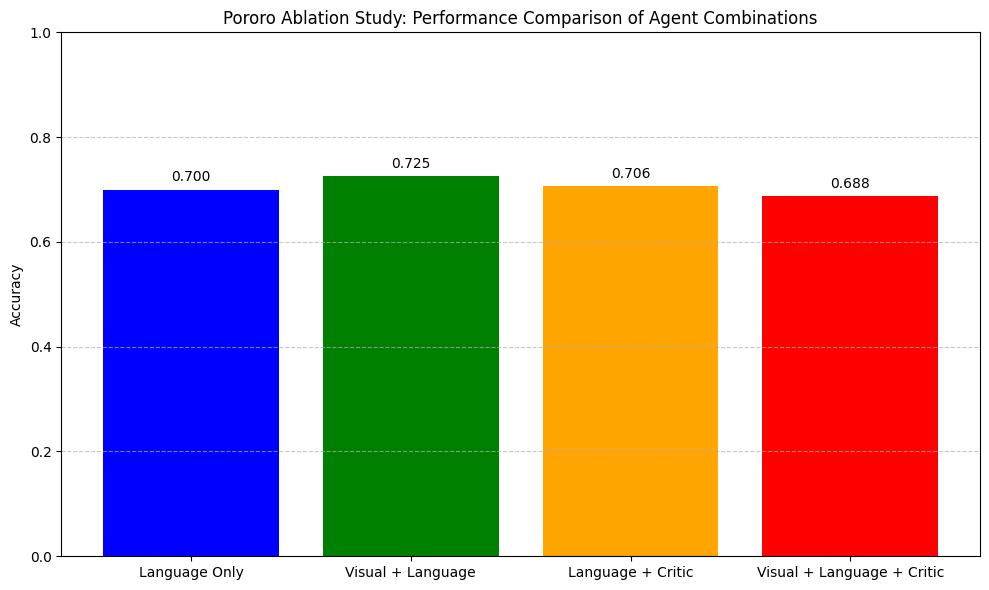


Comparison results saved to: /Users/wt/PythonProjects/Multi_Agent_Cartoon/results/ablation/pororo_ablation_comparison_20250430_190607.csv
Final comparison data:
                Configuration  Accuracy
0               Language Only   0.70000
1           Visual + Language   0.72500
2           Language + Critic   0.70625
3  Visual + Language + Critic   0.68750


In [ ]:
if not all_accuracies:
    print("No accuracy results in memory. Attempting to load from CSV files...")
    
    # Define configuration names we expect to find
    expected_configs = [
        'language', 
        'visual_language', 
        'language_critic', 
        'visual_language_critic'
    ]
    
    # Safe model name for file pattern matching
    safe_model_name = MODEL_NAME.replace('-', '_').replace('.', '_')
    # Define results_dir variable here to avoid undefined reference
    base_results_dir = os.path.join(os.getcwd(), "results")
    ablation_results_dir = os.path.join(base_results_dir, "ablation")
    
    # Load accuracies from CSV files if they exist
    for config in expected_configs:
        file_path = os.path.join(ablation_results_dir, f'pororo_ablation_{config}_{safe_model_name}.csv')
        try:
            if (os.path.exists(file_path)):
                df = pd.read_csv(file_path)
                # Get the last row which should be the Average row
                avg_row = df[df['question_id'] == 'Average']
                if not avg_row.empty and 'accuracy' in avg_row.columns:
                    all_accuracies[config] = float(avg_row['accuracy'].iloc[0])
                    print(f"Loaded accuracy for {config}: {all_accuracies[config]:.4f}")
                else:
                    # Calculate average from individual rows
                    regular_rows = df[df['question_id'] != 'Average']
                    if not regular_rows.empty and 'accuracy' in regular_rows.columns:
                        all_accuracies[config] = float(regular_rows['accuracy'].mean())
                        print(f"Calculated accuracy for {config}: {all_accuracies[config]:.4f}")
        except Exception as e:
            print(f"Error loading results for {config}: {e}")

# If we still don't have accuracy values, use the ones from the notebook state
# Safely access the global accuracies variable if it exists
if 'accuracies' in globals():
    local_accuracies = globals()['accuracies'] if globals()['accuracies'] else []
else:
    local_accuracies = []

if not all_accuracies and local_accuracies:
    # Use the current experiment's results if available
    avg_accuracy = np.mean(local_accuracies) if local_accuracies else 0
    config_name = ''
    if ENABLE_VISUAL_AGENT:
        config_name += 'visual_'
    if ENABLE_LANGUAGE_AGENT:
        config_name += 'language'
    if ENABLE_CRITIC_AGENT:
        config_name += '_critic'
    
    if config_name:
        all_accuracies[config_name] = avg_accuracy
        print(f"Using current experiment accuracy for {config_name}: {avg_accuracy:.4f}")

# Create the results dictionary for visualization
results = {
    "Language Only": all_accuracies.get('language', 0),
    "Visual + Language": all_accuracies.get('visual_language', 0),
    "Language + Critic": all_accuracies.get('language_critic', 0),
    "Visual + Language + Critic": all_accuracies.get('visual_language_critic', 0)
}

# Print the values we're using
print("\nAccuracy values used for visualization:")
for config, accuracy in results.items():
    print(f"{config}: {accuracy:.4f}")

# Create a folder to save figures if not exist
os.makedirs("saved_figures", exist_ok=True)

# Generate timestamp for unique figure name
timestamp = time.strftime("%Y%m%d_%H%M%S")
config_name = f"ablation_comparison_{timestamp}"

# Create the visualization
plt.figure(figsize=(10, 6))
bars = plt.bar(results.keys(), results.values(), color=['blue', 'green', 'orange', 'red'])
plt.ylim(0, 1.0)
plt.ylabel('Accuracy')
plt.title('Pororo Ablation Study: Performance Comparison of Agent Combinations')

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.01,
            f'{height:.3f}', ha='center', va='bottom')

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

# Save the figure with a unique name
plt.savefig(f"saved_figures/pororo_{config_name}.png", dpi=300)
print(f"Visualization saved to: saved_figures/pororo_{config_name}.png")

plt.show()

# Save the comparison results to CSV
comparison_df = pd.DataFrame([results], index=['Accuracy']).T.reset_index()
comparison_df.columns = ['Configuration', 'Accuracy']
timestamp = time.strftime("%Y%m%d_%H%M%S")
comparison_path = os.path.join(os.getcwd(), "results", "ablation", f"pororo_ablation_comparison_{timestamp}.csv")

# Create results directory if it doesn't exist
os.makedirs(os.path.dirname(comparison_path), exist_ok=True)

# Save the comparison file
comparison_df.to_csv(comparison_path, index=False)
print(f"\nComparison results saved to: {comparison_path}")
print(f"Final comparison data:\n{comparison_df}")